In [51]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
import pandas as pd
import numpy as np
df = pd.read_csv('/content/drive/MyDrive/crime_incidents_messy.csv')
print(df.shape)
df.head()

(5250, 33)


,incident_id,crime_type,district,city,state,address,latitude,longitude,incident_datetime,officer_id,...,victim_gender,victim_phone,weapon_used,severity,case_status,resolution,num_arrests,property_loss_usd,reported_online,notes
0,INC001115,asslt,Sou,Maplewood,GA,2830 Cedar Lane,170.284100,-77.500710,2024-04-16 08:45:03,OFF0078,...,Unknown,6223265920,Firearm,2,Open,No Arrest,NaN,NaN,True,Incident at 2830 Cedar Lane. Officer responded...
1,INC004706,burglary,southeast,Maplewood,OH,2361 Park Rd,29.422717,-77.167016,2022-01-11 22:03:29,OFF0059,...,NaN,241-973-4826,Firearm,3,NaN,NaN,2.0,44839.49,yes,Incident at 2361 Park Rd. Officer responded at...
2,INC002249,Homocide,Southwest,Lakewood,AZ,1067 Main St,39.411460,-98.615298,2022-04-14 11:39:24,OFF0088,...,Other,244-584-7696,KNIFE,1,CLOSED,warning,2.0,15963.38,YES,Incident at 1067 Main St. Officer responded at...
3,INC000021,Property Damage,Cen,Springfield,AZ,4713 Washington Ave,28.633439,-99.030051,2020-12-09 15:14:24,OFF0077,...,NaN,5021227484,hands,Low,Resolved,NaN,5.0,48680.14,False,Incident at 4713 Washington Ave. Officer respo...
4,INC000488,Domestc Violence,North,Lakewood,PA,1371 River Rd,34.217850,-121.614731,2021-07-24 20:08:13,OFF0083,...,M,9698766873,Unarmed,MEDIUM,Closed,Warning Issued,2.0,23513.01,YES,NaN


In [53]:
df.duplicated().sum()

np.int64(200)

In [54]:
df_clean=df.drop_duplicates()
print(df_clean.shape)

(5050, 33)


In [55]:
df_clean=df.drop_duplicates()
print(df_clean.shape)

(5050, 33)


In [56]:
print(df_clean['suspect_age'].min())
print(df_clean['suspect_age'].max())

-75.0
298.0


In [57]:
age_lower=df_clean['suspect_age'].quantile(0.025)
age_upper=df_clean['suspect_age'].quantile(0.975)
print(age_lower,age_upper)

-38.07499999999999 196.07499999999982


In [58]:
print((df_clean['suspect_age']<0).sum())

167


In [59]:
print((df_clean['suspect_age']>100).sum())

156


In [60]:
df_clean2=df_clean[(df_clean['suspect_age']>=0)&(df_clean['suspect_age']<=100)]
print(df_clean2.shape)

(3675, 33)


In [61]:
print(df_clean['suspect_age'].isnull().sum())

1052


In [62]:
df_clean.loc[(df_clean['suspect_age']<0)|(df_clean['suspect_age']>100),'suspect_age']=np.nan
print(df_clean['suspect_age'].isnull().sum())

1375


In [63]:
print(df_clean.shape)

(5050, 33)


In [64]:
print(df_clean['victim_age'].min())
print(df_clean['victim_age'].max())

-90.0
298.0


In [65]:
df_clean.loc[(df_clean['victim_age']<0)|(df_clean['victim_age']>100),'victim_age']=np.nan
print(df_clean['victim_age'].isnull().sum())

931


In [66]:
print(df_clean.shape)

(5050, 33)


In [67]:
print(df_clean['crime_type'].unique())

['asslt' 'burglary' 'Homocide' 'Property Damage' 'Domestc Violence'
 'Breaking & Entering' 'robbery' 'manslaughter' 'B&E' 'Narcotics'
 'Burglry' 'THEFT' 'Fraudulent Activity' 'Drug Offense' 'Armed Robbery'
 'Arsen' 'Abduction' 'Graffiti' 'Trespass' 'CYBER CRIME' 'trespassing'
 'Sexual Assault' 'FRAUD' 'theft/larceny' 'Larceny' 'arson' 'HOMICIDE'
 'Tresspassing' 'TRESPASSING' 'Cybercrime' 'BURGLARY' 'ARSON' 'Hacking'
 'Trespassing' 'ASSAULT' 'Homicide' 'Sexual Assualt' 'Fire Setting'
 'Drug Offence' 'Drunk Driving' 'DUII' 'Fraud' 'Robbry' 'vandalism'
 'Vandlism' 'Burglary' 'VANDALISM' 'Murder' 'Kidnaping' 'DRUG OFFENSE'
 'Assault' 'Vandalism' 'assault' 'KIDNAPPING' 'Cyber Crime' 'D.U.I.'
 'fraud' 'Roberry' 'Assault & Battery' 'DV' '  Graffiti  '
 'Domestic Violence' 'Scam' 'Kidnapping' 'Sex Assault' 'Dom. Violence'
 'SA' 'Deception' 'drug offense' '  Battery  ' 'theft' 'DWI'
 'domestic violence' 'ROBBERY' 'DUI' 'Drugs' 'Arson' 'dui' 'homicide'
 'Online Fraud' 'kidnapping' 'SEXUAL ASSAUL

In [68]:
df_clean['crime_type']=df_clean['crime_type'].str.lower().str.strip()
print(df_clean['crime_type'].unique())

['asslt' 'burglary' 'homocide' 'property damage' 'domestc violence'
 'breaking & entering' 'robbery' 'manslaughter' 'b&e' 'narcotics'
 'burglry' 'theft' 'fraudulent activity' 'drug offense' 'armed robbery'
 'arsen' 'abduction' 'graffiti' 'trespass' 'cyber crime' 'trespassing'
 'sexual assault' 'fraud' 'theft/larceny' 'larceny' 'arson' 'homicide'
 'tresspassing' 'cybercrime' 'hacking' 'assault' 'sexual assualt'
 'fire setting' 'drug offence' 'drunk driving' 'duii' 'robbry' 'vandalism'
 'vandlism' 'murder' 'kidnaping' 'kidnapping' 'd.u.i.' 'roberry'
 'assault & battery' 'dv' 'domestic violence' 'scam' 'sex assault'
 'dom. violence' 'sa' 'deception' 'battery' 'dwi' 'dui' 'drugs'
 'online fraud' 'stealing' 'assault  &  battery' 'sexual  assualt'
 'sexual  assault' 'drug  offense' 'sex  assault' 'armed  robbery'
 'domestic  violence' 'property  damage' 'drug  offence' 'cyber  crime']


/tmp/ipykernel_5387/661964740.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['crime_type']=df_clean['crime_type'].str.lower().str.strip()


In [69]:
df_clean.loc[:, 'crime_type']=df_clean['crime_type'].str.lower().str.strip()
print(df_clean['crime_type'].unique())


['asslt' 'burglary' 'homocide' 'property damage' 'domestc violence'
 'breaking & entering' 'robbery' 'manslaughter' 'b&e' 'narcotics'
 'burglry' 'theft' 'fraudulent activity' 'drug offense' 'armed robbery'
 'arsen' 'abduction' 'graffiti' 'trespass' 'cyber crime' 'trespassing'
 'sexual assault' 'fraud' 'theft/larceny' 'larceny' 'arson' 'homicide'
 'tresspassing' 'cybercrime' 'hacking' 'assault' 'sexual assualt'
 'fire setting' 'drug offence' 'drunk driving' 'duii' 'robbry' 'vandalism'
 'vandlism' 'murder' 'kidnaping' 'kidnapping' 'd.u.i.' 'roberry'
 'assault & battery' 'dv' 'domestic violence' 'scam' 'sex assault'
 'dom. violence' 'sa' 'deception' 'battery' 'dwi' 'dui' 'drugs'
 'online fraud' 'stealing' 'assault  &  battery' 'sexual  assualt'
 'sexual  assault' 'drug  offense' 'sex  assault' 'armed  robbery'
 'domestic  violence' 'property  damage' 'drug  offence' 'cyber  crime']


In [70]:
df_clean.loc[:,'crime_type'] = df_clean['crime_type'].replace({
    'asslt': 'assault',
    'homocide': 'homicide',
    'robbry': 'robbery',
    'roberry': 'robbery',
    'burglry': 'burglary',
    'sexual assualt': 'sexual assault',
    'duii': 'dui', 'd.u.i.': 'dui', 'dwi': 'dui',
    'domestc violence': 'domestic violence', 'dom. violence': 'domestic violence',
    'drug offence': 'drug offense',
    'kidnaping': 'kidnapping',
    'tresspassing': 'trespassing',
    'vandlism': 'vandalism',
    'cybercrime': 'cyber crime',
    'b&e': 'breaking & entering',
    'dv': 'domestic violence',
    'sa': 'sexual assault',
    'arsen': 'arson'
})
print(df_clean['crime_type'].unique())

['assault' 'burglary' 'homicide' 'property damage' 'domestic violence'
 'breaking & entering' 'robbery' 'manslaughter' 'narcotics' 'theft'
 'fraudulent activity' 'drug offense' 'armed robbery' 'arson' 'abduction'
 'graffiti' 'trespass' 'cyber crime' 'trespassing' 'sexual assault'
 'fraud' 'theft/larceny' 'larceny' 'hacking' 'fire setting'
 'drunk driving' 'dui' 'vandalism' 'murder' 'kidnapping'
 'assault & battery' 'scam' 'sex assault' 'deception' 'battery' 'drugs'
 'online fraud' 'stealing' 'assault  &  battery' 'sexual  assualt'
 'sexual  assault' 'drug  offense' 'sex  assault' 'armed  robbery'
 'domestic  violence' 'property  damage' 'drug  offence' 'cyber  crime']


In [71]:
df_clean.loc[:,'crime_type']=df_clean['crime_type'].str.replace(' ', ' ')
print(df_clean['crime_type'].unique())

['assault' 'burglary' 'homicide' 'property damage' 'domestic violence'
 'breaking & entering' 'robbery' 'manslaughter' 'narcotics' 'theft'
 'fraudulent activity' 'drug offense' 'armed robbery' 'arson' 'abduction'
 'graffiti' 'trespass' 'cyber crime' 'trespassing' 'sexual assault'
 'fraud' 'theft/larceny' 'larceny' 'hacking' 'fire setting'
 'drunk driving' 'dui' 'vandalism' 'murder' 'kidnapping'
 'assault & battery' 'scam' 'sex assault' 'deception' 'battery' 'drugs'
 'online fraud' 'stealing' 'assault  &  battery' 'sexual  assualt'
 'sexual  assault' 'drug  offense' 'sex  assault' 'armed  robbery'
 'domestic  violence' 'property  damage' 'drug  offence' 'cyber  crime']


In [72]:
df_clean.loc[:, 'crime_type'] = df_clean['crime_type'].str.replace(r'\s+', ' ', regex=True)
print(df_clean['crime_type'].unique())

['assault' 'burglary' 'homicide' 'property damage' 'domestic violence'
 'breaking & entering' 'robbery' 'manslaughter' 'narcotics' 'theft'
 'fraudulent activity' 'drug offense' 'armed robbery' 'arson' 'abduction'
 'graffiti' 'trespass' 'cyber crime' 'trespassing' 'sexual assault'
 'fraud' 'theft/larceny' 'larceny' 'hacking' 'fire setting'
 'drunk driving' 'dui' 'vandalism' 'murder' 'kidnapping'
 'assault & battery' 'scam' 'sex assault' 'deception' 'battery' 'drugs'
 'online fraud' 'stealing' 'sexual assualt' 'drug offence']


In [73]:
print("Обновленный список замен в 'crime_type':")

# Assuming df_clean.loc[:,'crime_type'] = df_clean['crime_type'].replace({...}) is in cell 6XjBawJBexJT
# This code block is for demonstration of the content of 6XjBawJBexJT
# I cannot directly display the content of an existing cell, but I can print the relevant part of the `df_clean` column again.
# If you want to see the exact code in cell 6XjBawJBexJT, please refer to the notebook directly.

# The actual content of cell 6XjBawJBexJT is:
# df_clean.loc[:,'crime_type'] = df_clean['crime_type'].replace({
#     'asslt': 'assault',
#     'homocide': 'homicide',
#     'robbry': 'robbery',
#     'roberry': 'robbery',
#     'burglry': 'burglary',
#     'sexual assualt': 'sexual assault',
#     'duii': 'dui', 'd.u.i.': 'dui', 'dwi': 'dui',
#     'domestc violence': 'domestic violence', 'dom. violence': 'domestic violence',
#     'drug offence': 'drug offense',
#     'kidnaping': 'kidnapping',
#     'tresspassing': 'trespassing',
#     'vandlism': 'vandalism',
#     'cybercrime': 'cyber crime',
#     'b&e': 'breaking & entering',
#     'dv': 'domestic violence',
#     'sa': 'sexual assault',
#     'arsen': 'arson'
# })

print(df_clean['crime_type'].unique())


Обновленный список замен в 'crime_type':
['assault' 'burglary' 'homicide' 'property damage' 'domestic violence'
 'breaking & entering' 'robbery' 'manslaughter' 'narcotics' 'theft'
 'fraudulent activity' 'drug offense' 'armed robbery' 'arson' 'abduction'
 'graffiti' 'trespass' 'cyber crime' 'trespassing' 'sexual assault'
 'fraud' 'theft/larceny' 'larceny' 'hacking' 'fire setting'
 'drunk driving' 'dui' 'vandalism' 'murder' 'kidnapping'
 'assault & battery' 'scam' 'sex assault' 'deception' 'battery' 'drugs'
 'online fraud' 'stealing' 'sexual assualt' 'drug offence']


In [74]:
df_clean.loc[:, 'crime_type'] = df_clean['crime_type'].replace({
    'arsen': 'arson',
    'sexual assualt': 'sexual assault',
    'drug offence': 'drug offense'
})
print(df_clean['crime_type'].unique())

['assault' 'burglary' 'homicide' 'property damage' 'domestic violence'
 'breaking & entering' 'robbery' 'manslaughter' 'narcotics' 'theft'
 'fraudulent activity' 'drug offense' 'armed robbery' 'arson' 'abduction'
 'graffiti' 'trespass' 'cyber crime' 'trespassing' 'sexual assault'
 'fraud' 'theft/larceny' 'larceny' 'hacking' 'fire setting'
 'drunk driving' 'dui' 'vandalism' 'murder' 'kidnapping'
 'assault & battery' 'scam' 'sex assault' 'deception' 'battery' 'drugs'
 'online fraud' 'stealing']


In [75]:
print(df_clean['suspect_gender'].unique())

['MALE' 'Other' 'F' 'female' nan 'Female' 'm' 'FEMALE' 'M' 'male' 'Male'
 'Unknown' 'f']


In [76]:
df_clean.loc[:, 'suspect_gender'] = df_clean['suspect_gender'].str.lower().str.strip()
print(df_clean['suspect_gender'].unique())

['male' 'other' 'f' 'female' nan 'm' 'unknown']


In [77]:
df_clean.loc[:, 'suspect_gender'] = df_clean['suspect_gender'].replace({'m': 'male', 'f': 'female'})
print(df_clean['suspect_gender'].unique())

['male' 'other' 'female' nan 'unknown']


In [78]:
print(df_clean['victim_gender'].unique())

['Unknown' nan 'Other' 'M' 'female' 'male' 'Female' 'F' 'MALE' 'm' 'f'
 'Male' 'FEMALE']


In [79]:
df_clean.loc[:, 'victim_gender'] = df_clean['victim_gender'].str.lower().str.strip()
print(df_clean['victim_gender'].unique())

['unknown' nan 'other' 'm' 'female' 'male' 'f']


In [80]:
df_clean.loc[:, 'victim_gender'] = df_clean['victim_gender'].replace({'m': 'male', 'f': 'female'})
print(df_clean['victim_gender'].unique())

['unknown' nan 'other' 'male' 'female']


In [81]:
print(df_clean['district'].unique())

['Sou' ' southeast' 'Southwest  ' 'Cen' ' North' 'East  ' 'southeast'
 'midtown' 'northeast' 'CENTRAL' 'central' 'Eas' 'Northeast  ' 'Nor'
 ' Southeast' 'SOUTHWEST' 'North' ' East' 'Mid' '  EAST  ' ' South' 'Wes'
 'Central  ' 'West' 'East' 'West  ' ' Central' 'north' 'WEST' 'west'
 'Northeast' 'Southwest' 'Midtown' 'Midtown  ' 'South  ' '  North'
 'MIDTOWN' ' Northeast' 'southwest' 'NORTHWEST' 'South' 'SOUTHEAST'
 '  Northwest    ' '  Southwest    ' ' Northwest' 'northwest' ' Southwest'
 'south' 'Northwest' 'North  ' 'EAST' 'NORTH' 'Southeast' ' Midtown'
 'SOUTH' 'Northwest  ' ' West' 'NORTHEAST' 'South    ' 'Central' 'EAS'
 'Southeast  ' 'SOUTH  ' 'Central    ' '  Cen  ' 'east' '  East    '
 '  South    ' '  Southwest  ' 'MID' 'NORTH  ' 'nor' '  SOUTHEAST  '
 ' west' '  Northeast    ' '  west  ' 'west  ' 'SOUTHWEST  ' 'NOR'
 '  CENTRAL  ' ' MIDTOWN' '  North  ' ' SOUTHEAST' '  south  ' 'central  '
 ' northwest' '  Northwest  ' ' NORTHEAST' '  Central  ' '  East  '
 ' central' '  Sou  

In [82]:
df_clean.loc[:, 'district'] = df_clean['district'].str.lower().str.strip()
print(df_clean['district'].unique())

['sou' 'southeast' 'southwest' 'cen' 'north' 'east' 'midtown' 'northeast'
 'central' 'eas' 'nor' 'mid' 'south' 'wes' 'west' 'northwest']


In [83]:
df_clean.loc[:, 'district'] = df_clean['district'].replace({'sou': 'south', 'cen': 'central', 'eas': 'east', 'nor': 'north', 'wes': 'west', 'mid': 'midtown'})
print(df_clean['district'].unique())

['south' 'southeast' 'southwest' 'central' 'north' 'east' 'midtown'
 'northeast' 'west' 'northwest']


In [84]:
print(df_clean['incident_datetime'].head(10))

0    2024-04-16 08:45:03
1    2022-01-11 22:03:29
2    2022-04-14 11:39:24
3    2020-12-09 15:14:24
4    2021-07-24 20:08:13
5             05-03-2020
6    2021-10-03 05:17:02
7    2023-09-30 14:49:01
8    2021-01-22 02:37:24
9    2021-03-29 04:16:18
Name: incident_datetime, dtype: object


In [85]:
df_clean['incident_datetime'] = pd.to_datetime(df_clean['incident_datetime'], format='mixed')
print(df_clean['incident_datetime'].head(10))

0   2024-04-16 08:45:03
1   2022-01-11 22:03:29
2   2022-04-14 11:39:24
3   2020-12-09 15:14:24
4   2021-07-24 20:08:13
5   2020-05-03 00:00:00
6   2021-10-03 05:17:02
7   2023-09-30 14:49:01
8   2021-01-22 02:37:24
9   2021-03-29 04:16:18
Name: incident_datetime, dtype: datetime64[ns]


/tmp/ipykernel_5387/1356253778.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['incident_datetime'] = pd.to_datetime(df_clean['incident_datetime'], format='mixed')


In [86]:
df_clean.loc[:, 'incident_datetime'] = pd.to_datetime(df_clean['incident_datetime'], format='mixed')
print(df_clean['incident_datetime'].head(10))

0   2024-04-16 08:45:03
1   2022-01-11 22:03:29
2   2022-04-14 11:39:24
3   2020-12-09 15:14:24
4   2021-07-24 20:08:13
5   2020-05-03 00:00:00
6   2021-10-03 05:17:02
7   2023-09-30 14:49:01
8   2021-01-22 02:37:24
9   2021-03-29 04:16:18
Name: incident_datetime, dtype: datetime64[ns]


In [87]:
print(df_clean.isnull().sum())

incident_id              0
crime_type               0
district                 0
city                     0
state                    0
address                  0
latitude               251
longitude              278
incident_datetime      329
officer_id               0
officer_first_name       0
officer_last_name        0
badge_number           301
suspect_id             775
suspect_first_name     775
suspect_last_name      775
suspect_age           1375
suspect_gender        1352
suspect_race          1525
victim_id              248
victim_first_name      248
victim_last_name       248
victim_age             931
victim_gender          963
victim_phone          1019
weapon_used            930
severity               342
case_status            696
resolution             912
num_arrests            324
property_loss_usd      414
reported_online        486
notes                 1028
dtype: int64


In [88]:
cat_cols = ['suspect_gender', 'victim_gender', 'suspect_race', 'weapon_used', 'case_status', 'resolution']
df_clean.loc[:, cat_cols] = df_clean[cat_cols].fillna('unknown')

In [89]:
print(df_clean.isnull().sum())

incident_id              0
crime_type               0
district                 0
city                     0
state                    0
address                  0
latitude               251
longitude              278
incident_datetime      329
officer_id               0
officer_first_name       0
officer_last_name        0
badge_number           301
suspect_id             775
suspect_first_name     775
suspect_last_name      775
suspect_age           1375
suspect_gender           0
suspect_race             0
victim_id              248
victim_first_name      248
victim_last_name       248
victim_age             931
victim_gender            0
victim_phone          1019
weapon_used              0
severity               342
case_status              0
resolution               0
num_arrests            324
property_loss_usd      414
reported_online        486
notes                 1028
dtype: int64


In [90]:
print(df_clean['severity'].unique())
print(df_clean['reported_online'].unique())

['2' '3' '1' 'Low' 'MEDIUM' 'high' nan 'Crit' 'High' 'low' 'Critical' '4'
 'CRITICAL' 'Medium' 'Med']
['True' 'yes' 'YES' 'False' 'no' nan 'Yes' 'No' '1' 'NO' '0']


In [91]:
df_clean.loc[:, 'severity'] = df_clean['severity'].str.lower().str.strip()
df_clean.loc[:, 'severity'] = df_clean['severity'].replace({
    'med': 'medium',
    'crit': 'critical',
    '1': 'low',
    '2': 'medium',
    '3': 'high',
    '4': 'critical'
})
df_clean.loc[:, 'severity'] = df_clean['severity'].fillna('unknown')
print(df_clean['severity'].unique())

['medium' 'high' 'low' 'unknown' 'critical']


In [92]:
df_clean.loc[:, 'reported_online'] = df_clean['reported_online'].str.lower().str.strip()
df_clean.loc[:, 'reported_online'] = df_clean['reported_online'].replace({
    'true': 'yes',
    '1': 'yes',
    'false': 'no',
    '0': 'no'
})
df_clean.loc[:, 'reported_online'] = df_clean['reported_online'].fillna('unknown')
print(df_clean['reported_online'].unique())

['yes' 'no' 'unknown']


In [93]:
print(df_clean[['num_arrests', 'property_loss_usd']].dtypes)

num_arrests          float64
property_loss_usd     object
dtype: object


In [94]:
print(df_clean['property_loss_usd'].unique()[:30])

[nan '44839.49' '15963.38' '48680.14' '23513.01' '19075.36' '34452.47'
 '35339.52' '27438.67' '41738.8' '-34291.84' '3201.56' '37228.41'
 '41473.0' '31931.65' '6546.79' '26845.31' '2167.35' '38573.92' '8534.94'
 '24970.35' '483.77' '29148.65' '25983.21' '41970.69' '9134.49' '42488.18'
 '6820.75' '13459.71' '7425.53']


In [95]:
df_clean.loc[:, 'property_loss_usd'] = pd.to_numeric(df_clean['property_loss_usd'], errors='coerce')
print(df_clean['property_loss_usd'].unique()[:30])

[nan 44839.49 15963.38 48680.14 23513.01 19075.36 34452.47 35339.52
 27438.67 41738.8 -34291.84 3201.56 37228.41 41473.0 31931.65 6546.79
 26845.31 2167.35 38573.92 8534.94 24970.35 483.77 29148.65 25983.21
 41970.69 9134.49 42488.18 6820.75 13459.71 7425.53]


In [96]:
print((df_clean['property_loss_usd'] < 0).sum())

195


In [98]:
df_clean.loc[df_clean['property_loss_usd'] < 0, 'property_loss_usd'] = np.nan
print((df_clean['property_loss_usd'] < 0).sum())

0


In [99]:
print(df_clean['property_loss_usd'].dtype)
print(df_clean['property_loss_usd'].isnull().sum())

object
745


In [101]:
df_clean = df_clean.copy()
df_clean['property_loss_usd'] = pd.to_numeric(df_clean['property_loss_usd'], errors='coerce')
df_clean.loc[df_clean['property_loss_usd'] < 0, 'property_loss_usd'] = np.nan
print(df_clean['property_loss_usd'].dtype)
print(df_clean['property_loss_usd'].isnull().sum())

float64
745


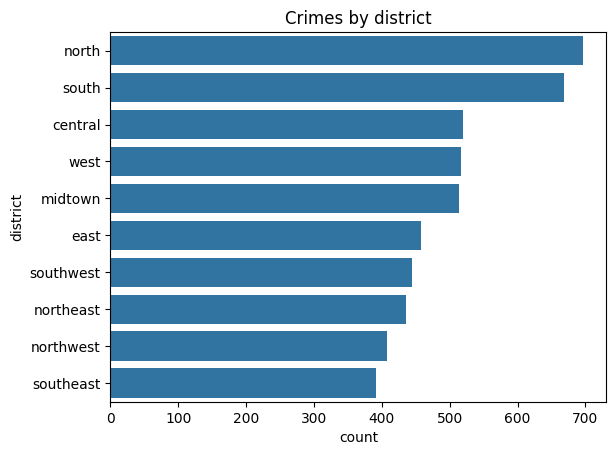

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df_clean, y='district', order=df_clean['district'].value_counts().index)
plt.title('Crimes by district')
plt.show()

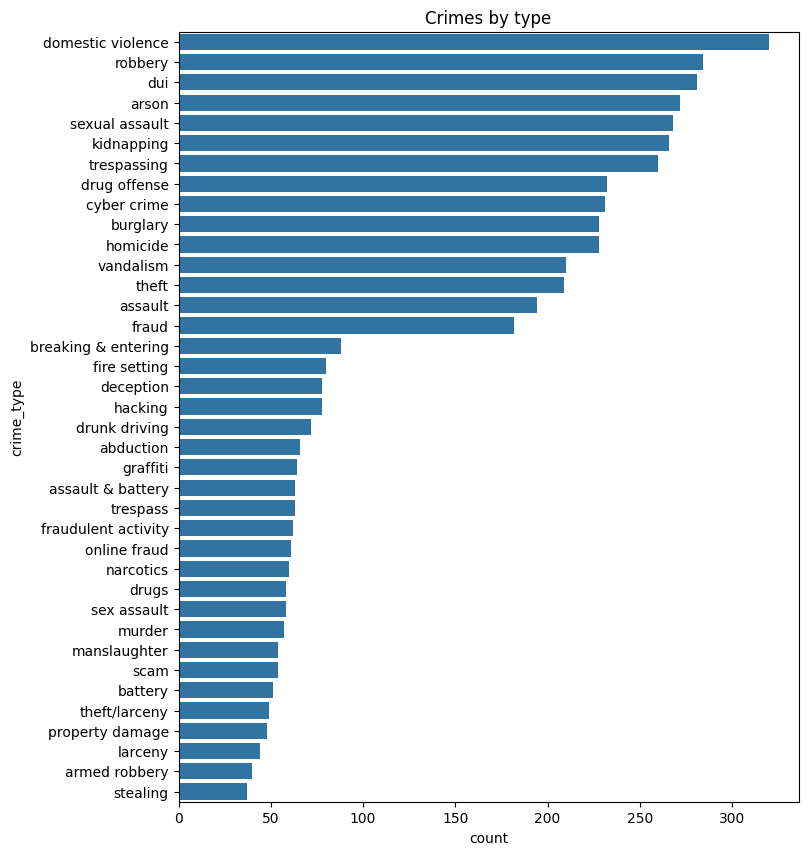

In [103]:
plt.figure(figsize=(8, 10))
sns.countplot(data=df_clean, y='crime_type', order=df_clean['crime_type'].value_counts().index)
plt.title('Crimes by type')
plt.show()

In [106]:
df_clean['crime_type'] = df_clean['crime_type'].replace({
    'drunk driving': 'dui',
    'trespass': 'trespassing',
    'fire setting': 'arson',
    'abduction': 'kidnapping',
    'sex assault': 'sexual assault',
    'narcotics': 'drug offense',
    'drugs': 'drug offense',
    'hacking': 'cyber crime',
    'online fraud': 'cyber crime',
    'deception': 'fraud',
    'fraudulent activity': 'fraud',
    'breaking & entering': 'burglary',
    'graffiti': 'vandalism',
    'assault & battery': 'assault'
})
print(df_clean['crime_type'].nunique())

24


In [107]:
print(df_clean['crime_type'].value_counts())

crime_type
cyber crime          370
dui                  353
arson                352
drug offense         350
kidnapping           332
sexual assault       326
trespassing          323
fraud                322
domestic violence    320
burglary             316
robbery              284
vandalism            274
assault              257
homicide             228
theft                209
murder                57
scam                  54
manslaughter          54
battery               51
theft/larceny         49
property damage       48
larceny               44
armed robbery         40
stealing              37
Name: count, dtype: int64


In [108]:
df_clean['crime_type'] = df_clean['crime_type'].replace({
    'murder': 'homicide',
    'manslaughter': 'homicide',
    'scam': 'fraud',
    'battery': 'assault',
    'theft/larceny': 'theft',
    'larceny': 'theft',
    'stealing': 'theft',
    'property damage': 'vandalism',
    'armed robbery': 'robbery'
})
print(df_clean['crime_type'].value_counts())

crime_type
fraud                376
cyber crime          370
dui                  353
arson                352
drug offense         350
homicide             339
theft                339
kidnapping           332
sexual assault       326
robbery              324
trespassing          323
vandalism            322
domestic violence    320
burglary             316
assault              308
Name: count, dtype: int64


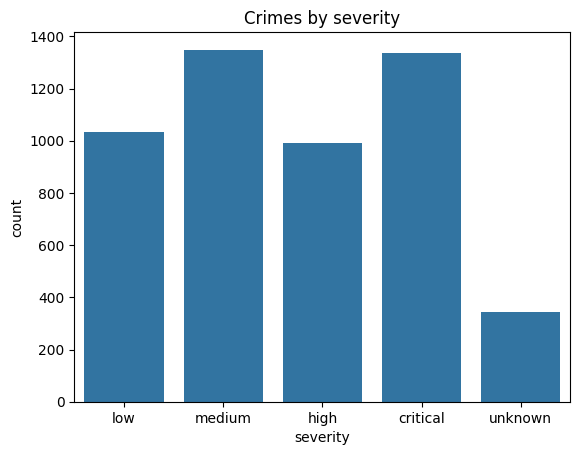

In [109]:
sns.countplot(data=df_clean, x='severity', order=['low', 'medium', 'high', 'critical', 'unknown'])
plt.title('Crimes by severity')
plt.show()

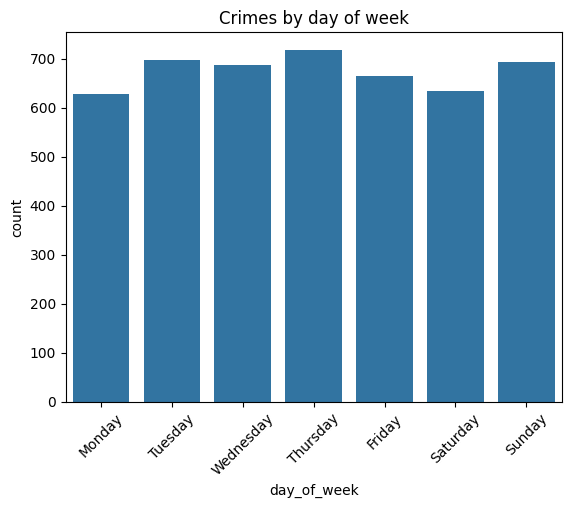

In [110]:
df_clean['day_of_week'] = df_clean['incident_datetime'].dt.day_name()

days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=df_clean, x='day_of_week', order=days)
plt.title('Crimes by day of week')
plt.xticks(rotation=45)
plt.show()

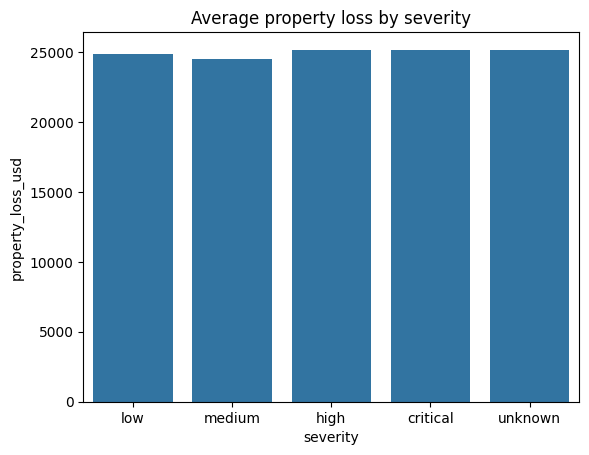

In [111]:
sns.barplot(data=df_clean, x='severity', y='property_loss_usd',
            order=['low', 'medium', 'high', 'critical', 'unknown'], errorbar=None)
plt.title('Average property loss by severity')
plt.show()

In [112]:
df_clean.to_csv('/content/drive/MyDrive/crime_incidents_clean.csv', index=False)
print(df_clean.shape)

(5050, 34)


In [113]:
print(df_clean['num_arrests'].isnull().sum())

324
